# Post 2 — Baselines: GLMs and GBMs

Runs the full 5-fold CV for:
- GLM Tweedie (raw + engineered features)
- XGBoost Tweedie (raw + engineered + GBM-optimised features)
- LightGBM Tweedie (raw + engineered + GBM-optimised features)

Results are saved to `results/cv/` and picked up by `post2_analysis.ipynb`.


In [1]:
import sys, os
# Works whether launched from project root or notebooks/
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import yaml
import warnings
warnings.filterwarnings('ignore')

from src.data.load_insurance import load_processed, get_dev_holdout, describe_dataset
from src.features.insurance_features import RawFeaturePipeline, EngineeredFeaturePipeline, GBMFeaturePipeline
from src.models.glm import PoissonGLM, GammaGLM, TweedieGLM
from src.models.gbm import XGBoostModel, LightGBMModel
from src.evaluation.cv_engine import run_cv, run_cv_hurdle

with open(os.path.join(project_root, 'configs/experiment_config.yaml')) as f:
    CONFIG = yaml.safe_load(f)

print('Imports OK')
print(f"Config: {CONFIG['modeling']['approaches']} | {CONFIG['data']['n_cv_folds']} CV folds")

Imports OK
Config: ['freqsev', 'tweedie', 'hurdle'] | 5 CV folds


## Step 1 — Data Loading

In [2]:
df = load_processed()
describe_dataset(df)

Shape:           (678013, 17)
Claim rate:      5.02% (34,060 policies with claims)
Mean exposure:   0.529

ClaimNb distribution:
claim_freq
0    643953
1     32178
2      1784
3        82
4        16
Name: count, dtype: int64

Pure premium (non-zero): mean=10417.8, p50=1504.2, p95=18909.8
Severity (claims>0):     mean=2222.2, p50=1172.0, p95=4659.5

Missing: {'severity': 653069}


In [3]:
splits = get_dev_holdout(df)

X_dev, X_holdout     = splits['X_dev'], splits['X_holdout']
y_dev, y_holdout     = splits['y_dev'], splits['y_holdout']
exp_dev, exp_holdout = splits['exposure_dev'], splits['exposure_holdout']
cv_folds             = splits['cv_folds']

print(f"Dev: {len(X_dev):,} | Holdout: {len(X_holdout):,}")
print(f"Claim rate — dev: {y_dev.claim_flag.mean():.2%} | holdout: {y_holdout.claim_flag.mean():.2%}")
print(f"CV folds: {len(cv_folds)} × ~{len(X_dev)//len(cv_folds):,} val rows")

Dev: 542,410 | Holdout: 135,603
Claim rate — dev: 5.02% | holdout: 5.02%
CV folds: 5 × ~108,482 val rows


## Step 2 — Feature Pipeline Smoke Test

In [4]:
sample_idx = np.arange(1000)
X_sample = X_dev.iloc[sample_idx]
y_sample = y_dev['pure_premium'].iloc[sample_idx]

raw_pipe = RawFeaturePipeline()
X_raw = raw_pipe.fit_transform(X_sample)
print(f"Raw:        {X_raw.shape} — {raw_pipe.feature_names_}")

eng_pipe = EngineeredFeaturePipeline()
X_eng = eng_pipe.fit_transform(X_sample, y=y_sample)
print(f"Engineered: {X_eng.shape} — {eng_pipe.feature_names_}")

gbm_pipe = GBMFeaturePipeline()
X_gbm = gbm_pipe.fit_transform(X_sample, y=y_sample)
print(f"GBM:        {X_gbm.shape} — {gbm_pipe.feature_names_}")

# Spot-check new business features
check = pd.DataFrame(X_gbm, columns=gbm_pipe.feature_names_)
print("\nGBM business features (first 3 rows):")
print(check[['BonusMalus','DrivAge','bm_excess','is_malus','young_driver',
             'senior_driver','young_x_power','vehicle_value_proxy']].head(3))

Raw:        (1000, 9) — ['Area', 'VehBrand', 'VehGas', 'Region', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']
Engineered: (1000, 11) — ['bm_bin', 'pow_group', 'age_band', 'log_density', 'vehage_bin', 'is_diesel', 'area_ordinal', 'Region_te', 'VehBrand_te', 'age_x_power', 'bm_x_age']
GBM:        (1000, 15) — ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'log_density', 'area_ordinal', 'is_diesel', 'Region_te', 'VehBrand_te', 'bm_excess', 'is_malus', 'young_driver', 'senior_driver', 'young_x_power', 'vehicle_value_proxy']

GBM business features (first 3 rows):
   BonusMalus  DrivAge  bm_excess  is_malus  young_driver  senior_driver  \
0        50.0     55.0        0.0       0.0           0.0            0.0   
1        50.0     55.0        0.0       0.0           0.0            0.0   
2        50.0     46.0        0.0       0.0           0.0            0.0   

   young_x_power  vehicle_value_proxy  
0            0.0                  5.0  
1            0.0                  5.

## Step 3 — GLM Smoke Test

In [5]:
N_SMOKE = 5_000
X_tr_sm = X_dev.iloc[:N_SMOKE]
y_tr_sm = y_dev.iloc[:N_SMOKE]
exp_tr_sm = exp_dev.iloc[:N_SMOKE].values

pipe_sm = RawFeaturePipeline()
X_sm = pipe_sm.fit_transform(X_tr_sm)

glm_poi = PoissonGLM()
glm_poi.fit(X_sm, y_tr_sm['claim_freq'].values, exposure=exp_tr_sm)
print(f"Poisson — mean rate: {glm_poi.predict(X_sm, exposure=exp_tr_sm).mean():.4f} "
      f"(actual: {(y_tr_sm.claim_freq / exp_tr_sm).mean():.4f})")

glm_tw = TweedieGLM()
glm_tw.fit(X_sm, y_tr_sm['pure_premium'].values, exposure=exp_tr_sm)
print(f"Tweedie — mean PP: {glm_tw.predict(X_sm, exposure=exp_tr_sm).mean():.2f} "
      f"(actual: {y_tr_sm.pure_premium.mean():.2f})")

sev_mask = y_tr_sm['severity'].notna().values
if sev_mask.sum() > 10:
    glm_gamma = GammaGLM()
    glm_gamma.fit(X_sm[sev_mask], y_tr_sm['severity'].dropna().values)
    print(f"Gamma — fit on {sev_mask.sum()} claims — OK")

print("\nGLM smoke tests: PASS")

Poisson — mean rate: 3.0490 (actual: 13.4170)
Tweedie — mean PP: 182.01 (actual: 178.25)
Gamma — fit on 119 claims — OK

GLM smoke tests: PASS


## Step 4 — GBM Hyperparameter Tuning

Tuning runs once on a 50K subsample of dev. Best params cached to `configs/`.
Skip if cached params already exist (run_cv will load them automatically).

In [6]:
TUNE_N = 50_000
tune_idx = np.random.default_rng(42).choice(len(X_dev), size=TUNE_N, replace=False)

X_tune_raw = RawFeaturePipeline().fit_transform(X_dev.iloc[tune_idx])
X_tune_eng = EngineeredFeaturePipeline().fit_transform(
    X_dev.iloc[tune_idx], y=y_dev['pure_premium'].iloc[tune_idx])
X_tune_gbm = GBMFeaturePipeline().fit_transform(
    X_dev.iloc[tune_idx], y=y_dev['pure_premium'].iloc[tune_idx])
y_tune = y_dev['pure_premium'].iloc[tune_idx].values
exp_tune = exp_dev.iloc[tune_idx].values

print(f"Tuning on {TUNE_N:,} rows: raw={X_tune_raw.shape}, eng={X_tune_eng.shape}, gbm={X_tune_gbm.shape}")

for label, X_tune in [('raw', X_tune_raw), ('engineered', X_tune_eng), ('gbm', X_tune_gbm)]:
    for ModelClass in [XGBoostModel, LightGBMModel]:
        m = ModelClass(approach='tweedie')
        m.tune(X_tune, y_tune, exposure_dev=exp_tune,
               n_trials=CONFIG['tuning']['n_trials'], features_label=label)

print("\nTuning complete. Params cached to configs/")

Tuning on 50,000 rows: raw=(50000, 9), eng=(50000, 11), gbm=(50000, 15)
Loaded cached XGB params from /Users/alexruppelt/Documents/Projects/tabpfn_analysis/configs/xgb_best_params_tweedie_raw.json
Loaded cached LGBM params from /Users/alexruppelt/Documents/Projects/tabpfn_analysis/configs/lgbm_best_params_tweedie_raw.json
Loaded cached XGB params from /Users/alexruppelt/Documents/Projects/tabpfn_analysis/configs/xgb_best_params_tweedie_engineered.json
Loaded cached LGBM params from /Users/alexruppelt/Documents/Projects/tabpfn_analysis/configs/lgbm_best_params_tweedie_engineered.json
Loaded cached XGB params from /Users/alexruppelt/Documents/Projects/tabpfn_analysis/configs/xgb_best_params_tweedie_gbm.json
Loaded cached LGBM params from /Users/alexruppelt/Documents/Projects/tabpfn_analysis/configs/lgbm_best_params_tweedie_gbm.json

Tuning complete. Params cached to configs/


## Step 5 — Full 5-Fold CV: GLMs

GLMs run on the full dev set — no subsampling needed.

In [7]:
glm_cv_raw = run_cv(
    model_factory=TweedieGLM,
    feature_pipeline_factory=RawFeaturePipeline,
    X_dev=X_dev, y_dev=y_dev, exposure_dev=exp_dev,
    cv_folds=cv_folds, approach='tweedie',
    model_name='GLM_Tweedie', features_label='raw',
)
print("GLM raw mean:", {k: round(v,4) for k,v in glm_cv_raw['mean_metrics'].items()})

glm_cv_eng = run_cv(
    model_factory=TweedieGLM,
    feature_pipeline_factory=EngineeredFeaturePipeline,
    X_dev=X_dev, y_dev=y_dev, exposure_dev=exp_dev,
    cv_folds=cv_folds, approach='tweedie',
    model_name='GLM_Tweedie', features_label='engineered',
)
print("GLM eng mean:", {k: round(v,4) for k,v in glm_cv_eng['mean_metrics'].items()})

GLM_Tweedie/raw/tweedie:  20%|██        | 1/5 [00:01<00:07,  1.88s/it]

  Fold 0: tweedie=92.3895 gini=0.2249


GLM_Tweedie/raw/tweedie:  40%|████      | 2/5 [00:03<00:05,  1.70s/it]

  Fold 1: tweedie=89.7742 gini=0.2858


GLM_Tweedie/raw/tweedie:  60%|██████    | 3/5 [00:05<00:03,  1.66s/it]

...

  Fold 2: tweedie=91.8141 gini=0.4390


GLM_Tweedie/engineered/tweedie:  80%|████████  | 4/5 [00:06<00:01,  1.66s/it]

  Fold 3: tweedie=89.1680 gini=0.4276


GLM_Tweedie/engineered/tweedie: 100%|██████████| 5/5 [00:08<00:00,  1.64s/it]

  Fold 4: tweedie=88.1280 gini=0.4510
GLM eng mean: {'tweedie_dev_1.5': 90.6096, 'poisson_dev': 1894.2213, 'gini': 0.3497, 'rmse': 14504.8344, 'mae': 500.8163}


## Step 6 — Full 5-Fold CV: GBMs (all three feature sets)

In [8]:
cv_results = {}
cv_results['GLM_raw']  = glm_cv_raw
cv_results['GLM_eng']  = glm_cv_eng

for model_cls, model_label in [(XGBoostModel, 'XGBoost'), (LightGBMModel, 'LightGBM')]:
    for pipe_cls, pipe_label in [
        (RawFeaturePipeline, 'raw'),
        (EngineeredFeaturePipeline, 'engineered'),
        (GBMFeaturePipeline, 'gbm'),
    ]:
        key = f"{model_label}_{pipe_label}"
        cv_results[key] = run_cv(
            model_factory=lambda cls=model_cls: cls(approach='tweedie'),
            feature_pipeline_factory=pipe_cls,
            X_dev=X_dev, y_dev=y_dev, exposure_dev=exp_dev,
            cv_folds=cv_folds, approach='tweedie',
            model_name=model_label, features_label=pipe_label,
        )

print("\n=== CV Summary (Tweedie deviance, lower is better) ===")
summary = pd.DataFrame(
    {k: v['mean_metrics'] for k, v in cv_results.items()}
).T.round(4)
print(summary)

print("\n--- Hypothesis: GBM pipeline beats raw and engineered for tree models ---")
for model_label in ['XGBoost', 'LightGBM']:
    td = {p: cv_results[f'{model_label}_{p}']['mean_metrics']['tweedie_dev_1.5']
          for p in ['raw', 'engineered', 'gbm']}
    best = min(td, key=td.get)
    print(f"  {model_label}: raw={td['raw']:.4f}, eng={td['engineered']:.4f}, gbm={td['gbm']:.4f} → best={best}")

print("\nAll CV results saved to results/cv/ — ready for post2_analysis.ipynb")

XGBoost/raw/tweedie:  20%|██        | 1/5 [00:00<00:02,  1.39it/s]

  Fold 0: tweedie=94.9963 gini=0.2700


XGBoost/raw/tweedie:  40%|████      | 2/5 [00:01<00:02,  1.47it/s]

  Fold 1: tweedie=93.4447 gini=0.2872


XGBoost/raw/tweedie:  60%|██████    | 3/5 [00:02<00:01,  1.48it/s]

...

  Fold 2: tweedie=75.6246 gini=0.5207


LightGBM/gbm/tweedie:  80%|████████  | 4/5 [00:04<00:01,  1.22s/it]

  Fold 3: tweedie=79.2225 gini=0.4382


LightGBM/gbm/tweedie: 100%|██████████| 5/5 [00:06<00:00,  1.23s/it]

  Fold 4: tweedie=78.4690 gini=0.5539

=== CV Summary (Tweedie deviance, lower is better) ===
                     tweedie_dev_1.5  poisson_dev    gini        rmse  \
GLM_raw                      89.5084    1874.9780  0.3751  14505.1762   
GLM_eng                      90.6096    1894.2213  0.3497  14504.8344   
XGBoost_raw                  89.7785    1781.1501  0.3433  14503.9237   
XGBoost_engineered           92.5775    1840.8781  0.3688  14602.0085   
XGBoost_gbm                  91.1937    1762.6882  0.4172  14504.1355   
LightGBM_raw                 80.0857    1685.3422  0.4001  14498.1855   
LightGBM_engineered          83.6347    1766.6254  0.4193  14512.2474   
LightGBM_gbm                 79.5486    1664.4111  0.4343  14497.7416   

                          mae  
GLM_raw              491.9364  
GLM_eng              500.8163  
XGBoost_raw          260.1104  
XGBoost_engineered   273.7805  
XGBoost_gbm          259.5507  
LightGBM_raw         272.9102  
LightGBM_engineered  280

## Step 7 — Hurdle Model: GLM Baseline

Stage 1 = LogisticRegression (claim occurrence), Stage 2 = GammaGLM (severity on claims-only).

In [9]:
from sklearn.linear_model import LogisticRegression

class LogisticClassifierWrapper:
    """Thin wrapper around sklearn LogisticRegression matching the model interface."""
    name = "LogisticRegression"

    def __init__(self):
        self._model = LogisticRegression(max_iter=500, random_state=42)

    def fit(self, X, y, exposure=None):
        self._model.fit(X, y.astype(int))
        return self

    def predict(self, X, exposure=None):
        return self._model.predict_proba(X)[:, 1]

    def clone(self):
        return LogisticClassifierWrapper()


# GLM hurdle: Logistic (stage 1) + GammaGLM (stage 2) — engineered features
glm_hurdle_eng = run_cv_hurdle(
    stage1_factory=LogisticClassifierWrapper,
    stage2_factory=GammaGLM,
    feature_pipeline_factory=EngineeredFeaturePipeline,
    X_dev=X_dev, y_dev=y_dev, exposure_dev=exp_dev,
    cv_folds=cv_folds,
    model_name='GLM_hurdle', features_label='engineered',
)
print("\nGLM hurdle mean:", {k: round(v,4) for k,v in glm_hurdle_eng['mean_metrics'].items()})

# Also run with GBM features for a fair comparison with TabPFN hurdle
glm_hurdle_gbm = run_cv_hurdle(
    stage1_factory=LogisticClassifierWrapper,
    stage2_factory=GammaGLM,
    feature_pipeline_factory=GBMFeaturePipeline,
    X_dev=X_dev, y_dev=y_dev, exposure_dev=exp_dev,
    cv_folds=cv_folds,
    model_name='GLM_hurdle', features_label='gbm',
)
print("GLM hurdle (gbm features) mean:", {k: round(v,4) for k,v in glm_hurdle_gbm['mean_metrics'].items()})

GLM_hurdle/engineered/hurdle:  20%|██        | 1/5 [00:04<00:18,  4.60s/it]

  Fold 0: tweedie=87.7103 gini=0.1180 claims_in_train=15,964


GLM_hurdle/engineered/hurdle:  40%|████      | 2/5 [00:09<00:14,  4.68s/it]

  Fold 1: tweedie=87.5811 gini=0.3621 claims_in_train=15,924


GLM_hurdle/engineered/hurdle:  60%|██████    | 3/5 [00:13<00:09,  4.66s/it]

...

  Fold 2: tweedie=87.9367 gini=0.4118 claims_in_train=15,941


GLM_hurdle/gbm/hurdle:  80%|████████  | 4/5 [00:21<00:05,  5.34s/it]

  Fold 3: tweedie=82.4167 gini=0.4010 claims_in_train=15,942


GLM_hurdle/gbm/hurdle: 100%|██████████| 5/5 [00:26<00:00,  5.35s/it]

  Fold 4: tweedie=82.6857 gini=0.4993 claims_in_train=16,009
GLM hurdle (gbm features) mean: {'tweedie_dev_1.5': 85.1551, 'poisson_dev': 1768.0621, 'gini': 0.3643, 'rmse': 14496.34, 'mae': 388.945, 'mean_s1_prob': 0.0502}


## Step 8 — Hurdle Model: XGBoost + LightGBM

Stage 1 = GBM binary classifier (claim occurrence), Stage 2 = GBM Gamma regressor (severity on claims-only).
GBM features for both stages. Default hyperparameters — same as tuned Tweedie for structure but no separate tuning for binary/severity objectives.

In [10]:
from src.models.gbm import XGBoostModel, LightGBMModel

for model_cls, model_label in [(XGBoostModel, 'XGBoost'), (LightGBMModel, 'LightGBM')]:
    key = f"{model_label}_hurdle_gbm"
    cv_results[key] = run_cv_hurdle(
        stage1_factory=lambda cls=model_cls: cls(approach='binary'),
        stage2_factory=lambda cls=model_cls: cls(approach='severity'),
        feature_pipeline_factory=GBMFeaturePipeline,
        X_dev=X_dev, y_dev=y_dev, exposure_dev=exp_dev,
        cv_folds=cv_folds,
        model_name=f'{model_label}_hurdle', features_label='gbm',
    )
    print(f"\n{model_label} hurdle mean:",
          {k: round(v, 4) for k, v in cv_results[key]['mean_metrics'].items()})

XGBoost_hurdle/gbm/hurdle:  20%|██        | 1/5 [00:01<00:04,  1.00s/it]

  Fold 0: tweedie=90.7035 gini=0.2007 claims_in_train=15,964


XGBoost_hurdle/gbm/hurdle:  40%|████      | 2/5 [00:02<00:03,  1.06s/it]

  Fold 1: tweedie=87.1845 gini=0.2074 claims_in_train=15,924


XGBoost_hurdle/gbm/hurdle:  60%|██████    | 3/5 [00:03<00:02,  1.03s/it]

...

  Fold 2: tweedie=82.7215 gini=0.4611 claims_in_train=15,941


LightGBM_hurdle/gbm/hurdle:  80%|████████  | 4/5 [00:06<00:01,  1.62s/it]

  Fold 3: tweedie=79.4089 gini=0.4439 claims_in_train=15,942


LightGBM_hurdle/gbm/hurdle: 100%|██████████| 5/5 [00:08<00:00,  1.64s/it]

  Fold 4: tweedie=79.5275 gini=0.4651 claims_in_train=16,009

LightGBM hurdle mean: {'tweedie_dev_1.5': 81.5632, 'poisson_dev': 1717.7213, 'gini': 0.381, 'rmse': 14496.0566, 'mae': 336.4376, 'mean_s1_prob': 0.0502}


## Step 8 — Holdout Evaluation: GLMs + GBMs

Refits all baseline models on full dev set, evaluates on holdout.
Saves to `results/holdout/metrics_baselines.parquet` — loaded by `post2_analysis.ipynb`.

In [11]:
from pathlib import Path
from src.evaluation.cv_engine import holdout_evaluation, holdout_evaluation_hurdle

# --- Tweedie models ---
model_configs_baselines = [
    {'model_factory': TweedieGLM, 'pipeline_factory': RawFeaturePipeline,
     'approach': 'tweedie', 'model_name': 'GLM_Tweedie', 'features_label': 'raw'},
    {'model_factory': TweedieGLM, 'pipeline_factory': EngineeredFeaturePipeline,
     'approach': 'tweedie', 'model_name': 'GLM_Tweedie', 'features_label': 'engineered'},
    {'model_factory': lambda: XGBoostModel(approach='tweedie'), 'pipeline_factory': RawFeaturePipeline,
     'approach': 'tweedie', 'model_name': 'XGBoost', 'features_label': 'raw'},
    {'model_factory': lambda: XGBoostModel(approach='tweedie'), 'pipeline_factory': EngineeredFeaturePipeline,
     'approach': 'tweedie', 'model_name': 'XGBoost', 'features_label': 'engineered'},
    {'model_factory': lambda: XGBoostModel(approach='tweedie'), 'pipeline_factory': GBMFeaturePipeline,
     'approach': 'tweedie', 'model_name': 'XGBoost', 'features_label': 'gbm'},
    {'model_factory': lambda: LightGBMModel(approach='tweedie'), 'pipeline_factory': RawFeaturePipeline,
     'approach': 'tweedie', 'model_name': 'LightGBM', 'features_label': 'raw'},
    {'model_factory': lambda: LightGBMModel(approach='tweedie'), 'pipeline_factory': EngineeredFeaturePipeline,
     'approach': 'tweedie', 'model_name': 'LightGBM', 'features_label': 'engineered'},
    {'model_factory': lambda: LightGBMModel(approach='tweedie'), 'pipeline_factory': GBMFeaturePipeline,
     'approach': 'tweedie', 'model_name': 'LightGBM', 'features_label': 'gbm'},
]

holdout_baselines = holdout_evaluation(
    model_configs=model_configs_baselines,
    X_dev=X_dev, y_dev=y_dev, exposure_dev=exp_dev,
    X_holdout=X_holdout, y_holdout=y_holdout, exposure_holdout=exp_holdout,
    tag='baselines',
)
print(holdout_baselines.round(4))

# --- Hurdle models: GLM, XGBoost, LightGBM ---
holdout_dir = Path(project_root) / 'results' / 'holdout'
hurdle_configs = [
    # GLM hurdle (Logistic + Gamma)
    dict(stage1_factory=LogisticClassifierWrapper,
         stage2_factory=GammaGLM,
         feature_pipeline_factory=GBMFeaturePipeline,
         model_name='GLM_hurdle', features_label='gbm'),
    # XGBoost hurdle
    dict(stage1_factory=lambda: XGBoostModel(approach='binary'),
         stage2_factory=lambda: XGBoostModel(approach='severity'),
         feature_pipeline_factory=GBMFeaturePipeline,
         model_name='XGBoost_hurdle', features_label='gbm'),
    # LightGBM hurdle
    dict(stage1_factory=lambda: LightGBMModel(approach='binary'),
         stage2_factory=lambda: LightGBMModel(approach='severity'),
         feature_pipeline_factory=GBMFeaturePipeline,
         model_name='LightGBM_hurdle', features_label='gbm'),
]

hurdle_preds = {}
hurdle_metrics = []
for cfg in hurdle_configs:
    preds, metrics = holdout_evaluation_hurdle(
        X_dev=X_dev, y_dev=y_dev, exposure_dev=exp_dev,
        X_holdout=X_holdout, y_holdout=y_holdout, exposure_holdout=exp_holdout,
        **cfg,
    )
    col = metrics['model']
    hurdle_preds[col] = preds
    hurdle_metrics.append(metrics)
    print(f"{col}: tweedie={metrics['tweedie_dev_1.5']:.4f}  gini={metrics['gini']:.4f}")

# Merge hurdle results into baselines parquet files
import pandas as pd
baseline_preds_df = pd.read_parquet(holdout_dir / 'predictions_baselines.parquet')
for col, arr in hurdle_preds.items():
    baseline_preds_df[col] = arr
baseline_preds_df.to_parquet(holdout_dir / 'predictions_baselines.parquet')

hurdle_metrics_df = pd.DataFrame(hurdle_metrics).set_index('model')
baseline_metrics_df = pd.read_parquet(holdout_dir / 'metrics_baselines.parquet')
pd.concat([baseline_metrics_df, hurdle_metrics_df]).to_parquet(holdout_dir / 'metrics_baselines.parquet')

print("\nSaved → results/holdout/metrics_baselines.parquet + predictions_baselines.parquet")

Holdout eval: GLM_Tweedie_raw_tweedie
Holdout eval: GLM_Tweedie_engineered_tweedie
Holdout eval: XGBoost_raw_tweedie
Holdout eval: XGBoost_engineered_tweedie
Holdout eval: XGBoost_gbm_tweedie
Holdout eval: LightGBM_raw_tweedie
Holdout eval: LightGBM_engineered_tweedie
Holdout eval: LightGBM_gbm_tweedie
                                tweedie_dev_1.5  poisson_dev    gini  \
model                                                                  
GLM_Tweedie_raw_tweedie                 89.6095    1601.2222  0.0995   
GLM_Tweedie_engineered_tweedie          92.1969    1644.8101  0.0245   
XGBoost_raw_tweedie                     92.6726    1464.8006  0.0823   
XGBoost_engineered_tweedie              88.7454    1488.5796  0.1512   
XGBoost_gbm_tweedie                     90.8353    1454.8504  0.1283   
LightGBM_raw_tweedie                    82.2879    1414.7547  0.1274   
LightGBM_engineered_tweedie             83.1269    1438.8210  0.0881   
LightGBM_gbm_tweedie                    81.9987 

## Step 9 — SHAP Interpretability: LightGBM (Best Baseline)

LightGBM is the best-performing baseline model (lowest Tweedie deviance).
Before comparing against TabPFN in `post2_tabpfn.ipynb`, we do a full
interpretability pass on this model in isolation.

**What we compute:**
- **TreeSHAP** — exact Shapley values via `shap.TreeExplainer` (fast: seconds for 2K rows)
- **Global importance** — mean |SHAP| bar chart + beeswarm summary
- **Dependence plots** — how BonusMalus, DrivAge, VehPower, and Density drive predictions
- **Waterfall plots** — individual policy explanations for 5 representative policies

**Model:** LightGBM Tweedie (power=1.5), GBMFeaturePipeline, tuned params from `configs/`.
**Sample:** 2,000 holdout rows for SHAP; same 50K dev subsample (seed=42) for refit.

Artifacts saved to `results/interpretability/` and `figures/post2/`.

But for TabPFN comparison, lets load raw feature impact first

In [24]:
import shap
import json
import time
import matplotlib.pyplot as plt
from pathlib import Path

interp_dir = Path(project_root) / 'results' / 'interpretability'
fig_dir    = Path(project_root) / 'figures' / 'post2'
interp_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# ── Refit LightGBM on 50K dev subsample with cached tuned params ─────────────
# Same seed and subsample size used throughout the project (deployment, TabPFN
# interpretability) so numbers are comparable across notebooks.
TRAIN_N  = 50_000
rng_fit  = np.random.default_rng(42)
fit_idx  = rng_fit.choice(len(X_dev), size=TRAIN_N, replace=False)

X_dev_sub = X_dev.iloc[fit_idx]
y_pp_sub  = y_dev['pure_premium'].iloc[fit_idx].values
exp_sub   = exp_dev.iloc[fit_idx].values

pipe_shap = RawFeaturePipeline()
X_fit_shap = pipe_shap.fit_transform(X_dev_sub, pd.Series(y_pp_sub))
feat_names = pipe_shap.feature_names_
print(f"Feature pipeline: {len(feat_names)} features — {feat_names}")

# Load cached tuned params (written by Step 4 tuning cell)
params_path = Path(project_root) / 'configs' / 'lgbm_best_params_tweedie_raw.json'
lgbm_params = {}
if params_path.exists():
    with open(params_path) as f:
        lgbm_params = json.load(f)
    print(f"\nLoaded cached LightGBM params: {lgbm_params}")
else:
    print(f"\nWARNING: {params_path} not found — fitting with default params. "
          "Run Step 4 tuning first for best results.")

t0 = time.time()
lgbm_shap = LightGBMModel(approach='tweedie', tweedie_power=1.5, params=lgbm_params)
lgbm_shap.fit(X_fit_shap, y_pp_sub, exposure=exp_sub)
print(f"LightGBM refit: {time.time()-t0:.1f}s  ({TRAIN_N:,} rows)")

# ── Holdout sample for SHAP ───────────────────────────────────────────────────
# TreeSHAP is fast — use 2,000 rows for stable importance estimates.
N_EXPLAIN = 2_000
rng_h     = np.random.default_rng(77)
shap_idx  = rng_h.choice(len(X_holdout), size=N_EXPLAIN, replace=False)

X_holdout_shap = pipe_shap.transform(X_holdout.iloc[shap_idx])
X_holdout_df   = X_holdout.iloc[shap_idx].reset_index(drop=True)
exp_holdout_shap = exp_holdout.iloc[shap_idx].values
y_holdout_shap   = y_holdout['pure_premium'].iloc[shap_idx].values

preds_lgbm = lgbm_shap.predict(X_holdout_shap)
print(f"\nHoldout SHAP sample: {N_EXPLAIN} rows  "
      f"pred range [{preds_lgbm.min():.2f}, {preds_lgbm.max():.2f}]")

Feature pipeline: 9 features — ['Area', 'VehBrand', 'VehGas', 'Region', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']

Loaded cached LightGBM params: {'num_leaves': 20, 'learning_rate': 0.011154984070934734, 'n_estimators': 152, 'min_child_samples': 9, 'subsample': 0.8542823567523073, 'colsample_bytree': 0.9343666431622274, 'reg_alpha': 0.003879134878250016, 'reg_lambda': 8.416916723646292}
LightGBM refit: 0.6s  (50,000 rows)

Holdout SHAP sample: 2000 rows  pred range [31.59, 556.97]


=== TreeSHAP: LightGBM (Tweedie) ===
Computed SHAP for 2000 rows in 0.09s
Array shape: (2000, 9)

Sanity check (log space, row 0): raw=5.1754  SHAP sum=5.1754

Feature importance (mean |SHAP| in log space):
BonusMalus    0.26230
Density       0.11732
DrivAge       0.11262
VehAge        0.07336
VehGas        0.06660
Region        0.03917
VehBrand      0.02786
VehPower      0.01570
Area          0.00236


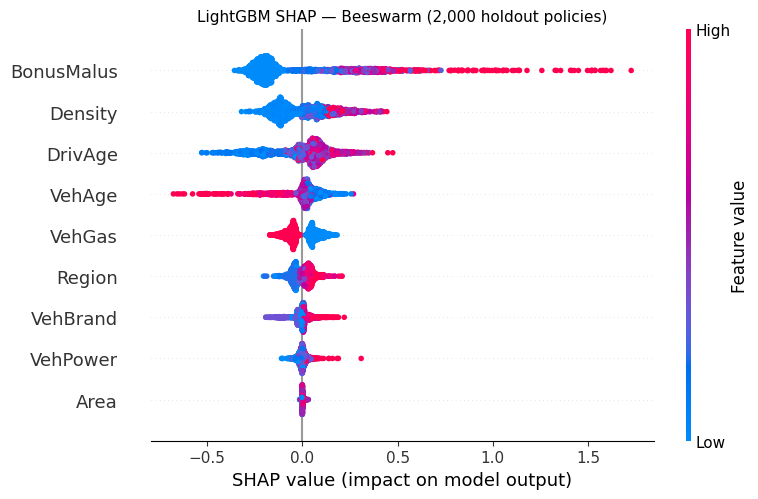


Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/shap_lgbm_beeswarm.png


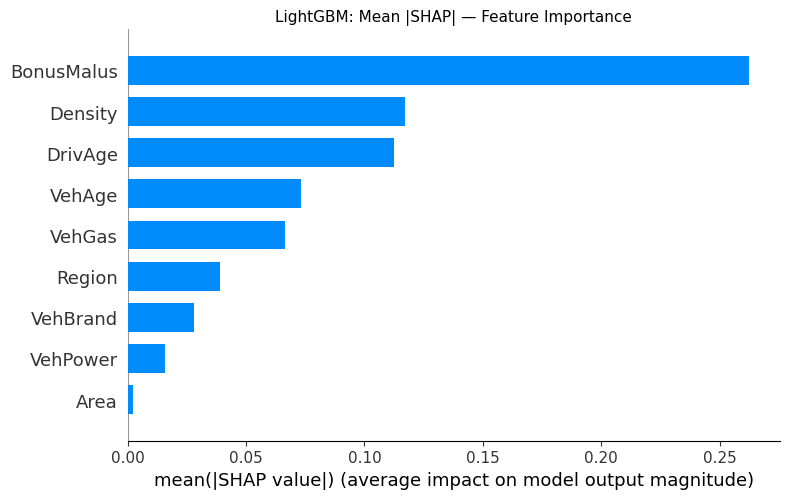

Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/shap_lgbm_importance_bar.png

Saved → results/interpretability/shap_values_lgbm.npy


In [25]:
# ── TreeSHAP — LightGBM ──────────────────────────────────────────────────────
# TreeSHAP exploits the tree structure for exact Shapley values in O(TLD²).
# For LightGBM this is natively supported; no approximation needed.
#
# The TreeExplainer computes SHAP values in the *log* space (LightGBM Tweedie
# uses a log link). shap_values[i,j] is the additive contribution of feature j
# to log(pred_i) relative to E[log(pred)].  The sum + expected_value = log(pred_i).

print("=== TreeSHAP: LightGBM (Tweedie) ===")
t0 = time.time()
explainer_lgbm = shap.TreeExplainer(lgbm_shap._model)
shap_values_lgbm = explainer_lgbm.shap_values(X_holdout_shap)   # (2000, 15)
t_shap = time.time() - t0
print(f"Computed SHAP for {N_EXPLAIN} rows in {t_shap:.2f}s")
print(f"Array shape: {shap_values_lgbm.shape}")

# Sanity check: SHAP sum + E[f(X)] ≈ model output (in log space for Tweedie)
raw_preds_log = lgbm_shap._model.predict(X_holdout_shap)
shap_check    = shap_values_lgbm[:3].sum(axis=1) + explainer_lgbm.expected_value
print(f"\nSanity check (log space, row 0): "
      f"raw={np.log(np.clip(raw_preds_log[0], 1e-10, None)):.4f}  "
      f"SHAP sum={shap_check[0]:.4f}")

# Global importance: mean |SHAP| per feature (in log space — rank-comparable)
importance_lgbm = np.abs(shap_values_lgbm).mean(axis=0)
feat_imp_df = pd.Series(importance_lgbm, index=feat_names).sort_values(ascending=False)
print("\nFeature importance (mean |SHAP| in log space):")
print(feat_imp_df.round(5).to_string())

# ── Beeswarm summary plot ─────────────────────────────────────────────────────
# Each dot = one policy; x = SHAP value (log scale contribution);
# colour = feature value (red=high, blue=low). Best overview of global patterns.
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(
    shap_values_lgbm,
    X_holdout_shap,
    feature_names=feat_names,
    plot_type='dot',
    max_display=15,
    show=False,
)
plt.title('LightGBM SHAP — Beeswarm (2,000 holdout policies)', fontsize=11)
plt.tight_layout()
fname_beeswarm = fig_dir / 'shap_lgbm_beeswarm.png'
plt.savefig(fname_beeswarm, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved → {fname_beeswarm}")

# ── Bar chart: mean |SHAP| ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(
    shap_values_lgbm,
    X_holdout_shap,
    feature_names=feat_names,
    plot_type='bar',
    max_display=15,
    show=False,
)
plt.title('LightGBM: Mean |SHAP| — Feature Importance', fontsize=11)
plt.tight_layout()
fname_bar = fig_dir / 'shap_lgbm_importance_bar.png'
plt.savefig(fname_bar, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname_bar}")

# Save raw SHAP values for use in post2_analysis.ipynb
np.save(interp_dir / 'shap_values_lgbm.npy', shap_values_lgbm)
np.save(interp_dir / 'shap_holdout_X_lgbm.npy', X_holdout_shap)
print(f"\nSaved → results/interpretability/shap_values_lgbm.npy")

## Now for main interpretability check

In [22]:
import shap
import json
import time
import matplotlib.pyplot as plt
from pathlib import Path

interp_dir = Path(project_root) / 'results' / 'interpretability'
fig_dir    = Path(project_root) / 'figures' / 'post2'
interp_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# ── Refit LightGBM on 50K dev subsample with cached tuned params ─────────────
# Same seed and subsample size used throughout the project (deployment, TabPFN
# interpretability) so numbers are comparable across notebooks.
TRAIN_N  = 50_000
rng_fit  = np.random.default_rng(42)
fit_idx  = rng_fit.choice(len(X_dev), size=TRAIN_N, replace=False)

X_dev_sub = X_dev.iloc[fit_idx]
y_pp_sub  = y_dev['pure_premium'].iloc[fit_idx].values
exp_sub   = exp_dev.iloc[fit_idx].values

pipe_shap = GBMFeaturePipeline()
X_fit_shap = pipe_shap.fit_transform(X_dev_sub, pd.Series(y_pp_sub))
feat_names = pipe_shap.feature_names_
print(f"Feature pipeline: {len(feat_names)} features — {feat_names}")

# Load cached tuned params (written by Step 4 tuning cell)
params_path = Path(project_root) / 'configs' / 'lgbm_best_params_tweedie_gbm.json'
lgbm_params = {}
if params_path.exists():
    with open(params_path) as f:
        lgbm_params = json.load(f)
    print(f"\nLoaded cached LightGBM params: {lgbm_params}")
else:
    print(f"\nWARNING: {params_path} not found — fitting with default params. "
          "Run Step 4 tuning first for best results.")

t0 = time.time()
lgbm_shap = LightGBMModel(approach='tweedie', tweedie_power=1.5, params=lgbm_params)
lgbm_shap.fit(X_fit_shap, y_pp_sub, exposure=exp_sub)
print(f"LightGBM refit: {time.time()-t0:.1f}s  ({TRAIN_N:,} rows)")

# ── Holdout sample for SHAP ───────────────────────────────────────────────────
# TreeSHAP is fast — use 2,000 rows for stable importance estimates.
N_EXPLAIN = 2_000
rng_h     = np.random.default_rng(77)
shap_idx  = rng_h.choice(len(X_holdout), size=N_EXPLAIN, replace=False)

X_holdout_shap = pipe_shap.transform(X_holdout.iloc[shap_idx])
X_holdout_df   = X_holdout.iloc[shap_idx].reset_index(drop=True)
exp_holdout_shap = exp_holdout.iloc[shap_idx].values
y_holdout_shap   = y_holdout['pure_premium'].iloc[shap_idx].values

preds_lgbm = lgbm_shap.predict(X_holdout_shap)
print(f"\nHoldout SHAP sample: {N_EXPLAIN} rows  "
      f"pred range [{preds_lgbm.min():.2f}, {preds_lgbm.max():.2f}]")

Feature pipeline: 15 features — ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'log_density', 'area_ordinal', 'is_diesel', 'Region_te', 'VehBrand_te', 'bm_excess', 'is_malus', 'young_driver', 'senior_driver', 'young_x_power', 'vehicle_value_proxy']

Loaded cached LightGBM params: {'num_leaves': 22, 'learning_rate': 0.013800488261266623, 'n_estimators': 101, 'min_child_samples': 57, 'subsample': 0.7585126522395964, 'colsample_bytree': 0.8956749320543134, 'reg_alpha': 2.993017981471946e-05, 'reg_lambda': 0.004385057593084603}
LightGBM refit: 0.4s  (50,000 rows)

Holdout SHAP sample: 2000 rows  pred range [37.12, 503.03]


=== TreeSHAP: LightGBM (Tweedie) ===
Computed SHAP for 2000 rows in 0.09s
Array shape: (2000, 15)

Sanity check (log space, row 0): raw=5.1546  SHAP sum=5.1546

Feature importance (mean |SHAP| in log space):
BonusMalus             0.25722
DrivAge                0.10758
log_density            0.09866
vehicle_value_proxy    0.06622
VehAge                 0.04544
VehBrand_te            0.03467
bm_excess              0.02783
Region_te              0.02709
VehPower               0.01653
area_ordinal           0.00210
young_x_power          0.00022
senior_driver          0.00020
is_diesel              0.00000
is_malus               0.00000
young_driver           0.00000


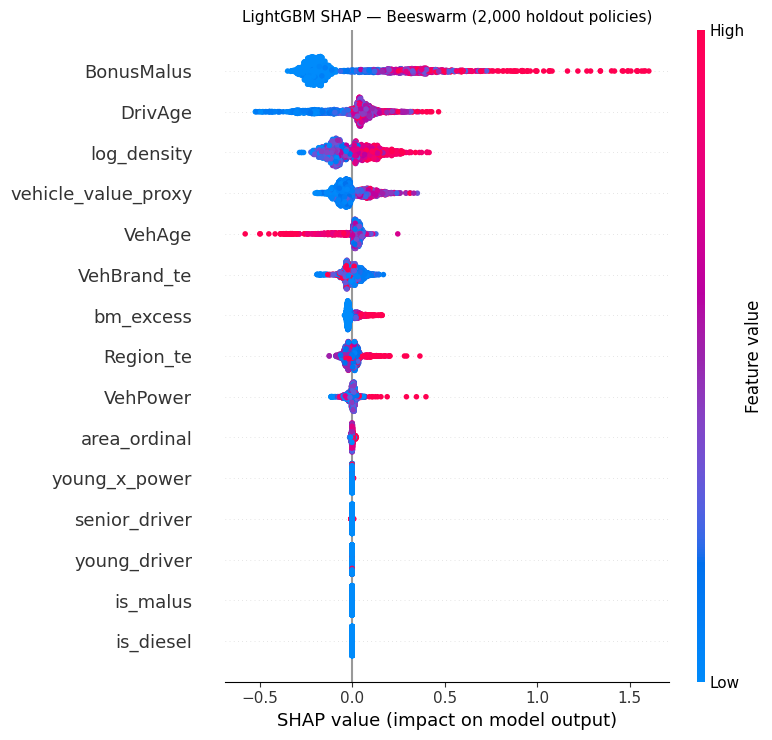


Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/shap_lgbm_beeswarm.png


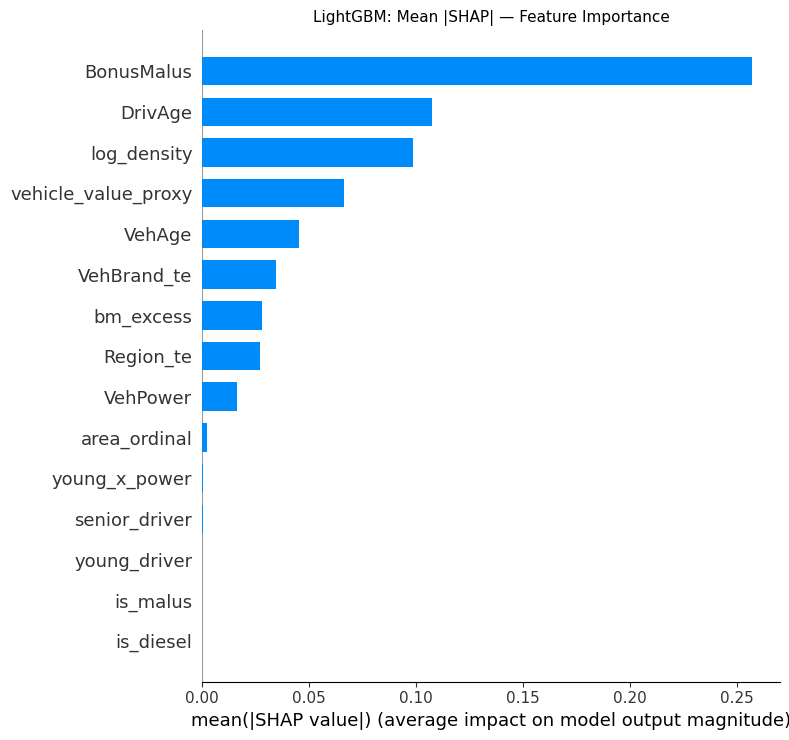

Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/shap_lgbm_importance_bar.png

Saved → results/interpretability/shap_values_lgbm.npy


In [18]:
# ── TreeSHAP — LightGBM ──────────────────────────────────────────────────────
# TreeSHAP exploits the tree structure for exact Shapley values in O(TLD²).
# For LightGBM this is natively supported; no approximation needed.
#
# The TreeExplainer computes SHAP values in the *log* space (LightGBM Tweedie
# uses a log link). shap_values[i,j] is the additive contribution of feature j
# to log(pred_i) relative to E[log(pred)].  The sum + expected_value = log(pred_i).

print("=== TreeSHAP: LightGBM (Tweedie) ===")
t0 = time.time()
explainer_lgbm = shap.TreeExplainer(lgbm_shap._model)
shap_values_lgbm = explainer_lgbm.shap_values(X_holdout_shap)   # (2000, 15)
t_shap = time.time() - t0
print(f"Computed SHAP for {N_EXPLAIN} rows in {t_shap:.2f}s")
print(f"Array shape: {shap_values_lgbm.shape}")

# Sanity check: SHAP sum + E[f(X)] ≈ model output (in log space for Tweedie)
raw_preds_log = lgbm_shap._model.predict(X_holdout_shap)
shap_check    = shap_values_lgbm[:3].sum(axis=1) + explainer_lgbm.expected_value
print(f"\nSanity check (log space, row 0): "
      f"raw={np.log(np.clip(raw_preds_log[0], 1e-10, None)):.4f}  "
      f"SHAP sum={shap_check[0]:.4f}")

# Global importance: mean |SHAP| per feature (in log space — rank-comparable)
importance_lgbm = np.abs(shap_values_lgbm).mean(axis=0)
feat_imp_df = pd.Series(importance_lgbm, index=feat_names).sort_values(ascending=False)
print("\nFeature importance (mean |SHAP| in log space):")
print(feat_imp_df.round(5).to_string())

# ── Beeswarm summary plot ─────────────────────────────────────────────────────
# Each dot = one policy; x = SHAP value (log scale contribution);
# colour = feature value (red=high, blue=low). Best overview of global patterns.
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(
    shap_values_lgbm,
    X_holdout_shap,
    feature_names=feat_names,
    plot_type='dot',
    max_display=15,
    show=False,
)
plt.title('LightGBM SHAP — Beeswarm (2,000 holdout policies)', fontsize=11)
plt.tight_layout()
fname_beeswarm = fig_dir / 'shap_lgbm_beeswarm.png'
plt.savefig(fname_beeswarm, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved → {fname_beeswarm}")

# ── Bar chart: mean |SHAP| ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(
    shap_values_lgbm,
    X_holdout_shap,
    feature_names=feat_names,
    plot_type='bar',
    max_display=15,
    show=False,
)
plt.title('LightGBM: Mean |SHAP| — Feature Importance', fontsize=11)
plt.tight_layout()
fname_bar = fig_dir / 'shap_lgbm_importance_bar.png'
plt.savefig(fname_bar, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname_bar}")

# Save raw SHAP values for use in post2_analysis.ipynb
np.save(interp_dir / 'shap_values_lgbm.npy', shap_values_lgbm)
np.save(interp_dir / 'shap_holdout_X_lgbm.npy', X_holdout_shap)
print(f"\nSaved → results/interpretability/shap_values_lgbm.npy")

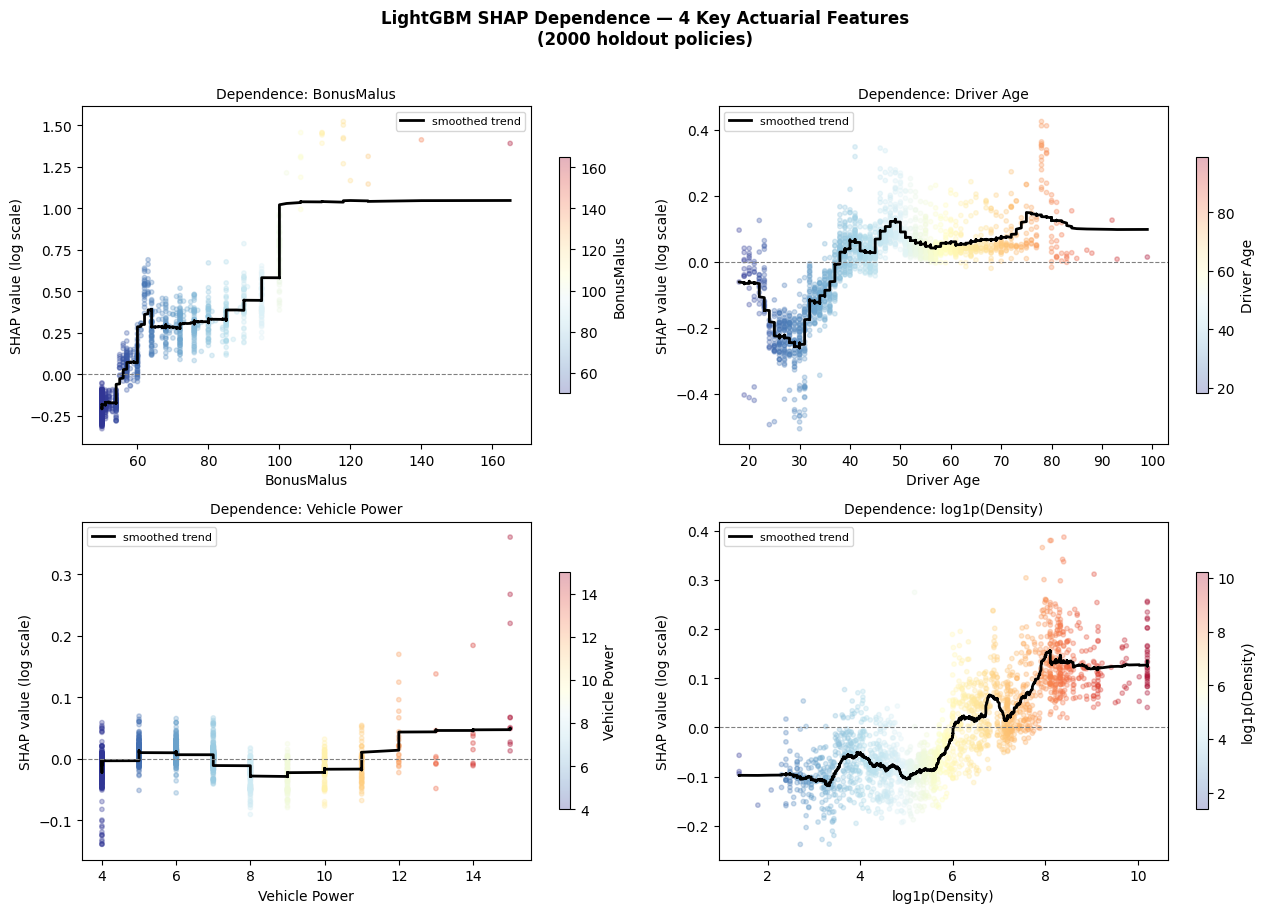

Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/shap_lgbm_dependence_4features.png
Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/shap_BonusMalus_LightGBM.png
Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/shap_DrivAge_LightGBM.png
Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/shap_VehPower_LightGBM.png
Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/shap_log_density_LightGBM.png


In [14]:
# ── SHAP Dependence Plots: 4 Key Actuarial Features ─────────────────────────
# Dependence plot: x = raw feature value, y = SHAP value (log contribution).
# The slope/shape tells us how LightGBM has learned the risk relationship.
#
# Expected shapes from actuarial theory:
#   BonusMalus — monotone increasing (higher BM = more malus = higher risk)
#   DrivAge    — U-shaped (young and elderly are riskier; peaks at ~22 and ~75)
#   VehPower   — increasing then flat (risk flattens above power ~10)
#   Density    — ambiguous (higher density = more urban = more small claims, but
#                also more TPBI complexity; log_density is the stored feature)
#
# We use raw feature values for BonusMalus, DrivAge, VehPower (from X_holdout_df)
# and the transformed log_density directly from X_holdout_shap.

from scipy.ndimage import uniform_filter1d

KEY_FEATURES_LGBM = [
    # (feat_name_in_pipeline, raw_values_source, x_label)
    ('BonusMalus',  X_holdout_df['BonusMalus'].values,  'BonusMalus'),
    ('DrivAge',     X_holdout_df['DrivAge'].values,      'Driver Age'),
    ('VehPower',    X_holdout_df['VehPower'].values,     'Vehicle Power'),
    ('log_density', None,                                'log1p(Density)'),  # from pipeline
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (feat_key, raw_x, x_label) in zip(axes, KEY_FEATURES_LGBM):
    feat_idx = feat_names.index(feat_key)
    shap_y   = shap_values_lgbm[:, feat_idx]
    x_vals   = (raw_x if raw_x is not None
                else X_holdout_shap[:, feat_idx])

    # Scatter — colour by feature value
    sc = ax.scatter(x_vals, shap_y, c=x_vals, cmap='RdYlBu_r',
                    alpha=0.30, s=10, rasterized=True)
    plt.colorbar(sc, ax=ax, shrink=0.7, label=x_label)

    # Smoothed trend
    sort_idx  = np.argsort(x_vals)
    window    = max(1, len(sort_idx) // 25)
    smoothed  = uniform_filter1d(shap_y[sort_idx], size=window)
    ax.plot(x_vals[sort_idx], smoothed, color='black', linewidth=2.0,
            label='smoothed trend')

    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel('SHAP value (log scale)', fontsize=10)
    ax.set_title(f'Dependence: {x_label}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('LightGBM SHAP Dependence — 4 Key Actuarial Features\n'
             f'({N_EXPLAIN} holdout policies)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
fname_dep = fig_dir / 'shap_lgbm_dependence_4features.png'
plt.savefig(fname_dep, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname_dep}")

# Also save individual panels (spec §9 format: shap_{feature}_{model}.png)
for feat_key, raw_x, x_label in KEY_FEATURES_LGBM:
    feat_idx = feat_names.index(feat_key)
    shap_y   = shap_values_lgbm[:, feat_idx]
    x_vals   = (raw_x if raw_x is not None else X_holdout_shap[:, feat_idx])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(x_vals, shap_y, c=x_vals, cmap='RdYlBu_r', alpha=0.30, s=10, rasterized=True)
    sort_idx = np.argsort(x_vals)
    smoothed = uniform_filter1d(shap_y[sort_idx], size=max(1, len(sort_idx)//25))
    ax.plot(x_vals[sort_idx], smoothed, color='black', linewidth=2.0)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xlabel(x_label); ax.set_ylabel('SHAP value (log scale)')
    ax.set_title(f'LightGBM SHAP: {x_label}', fontsize=10)
    plt.tight_layout()
    fname_i = fig_dir / f'shap_{feat_key}_LightGBM.png'
    plt.savefig(fname_i, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved → {fname_i}")

Selected policies:
  low_risk      row= 497  pred=37.1176  age=19  BM=50  power=7
  median_risk   row=1424  pred=95.9084  age=42  BM=50  power=7
  high_risk     row= 955  pred=503.0312  age=61  BM=125  power=6
  young_malus   row= 495  pred=294.9084  age=22  BM=118  power=4
  old_bonus     row=   1  pred=88.9702  age=75  BM=50  power=5


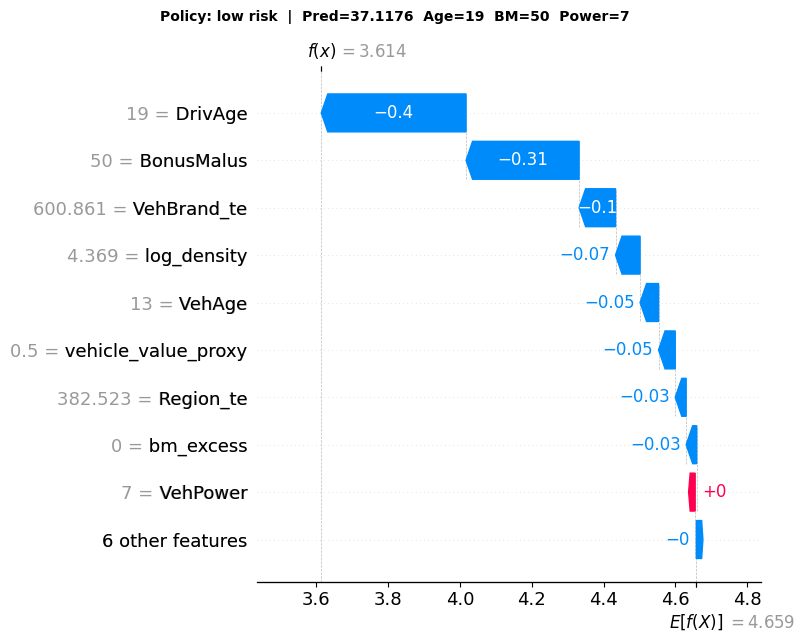

Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/waterfall_lgbm_low_risk.png


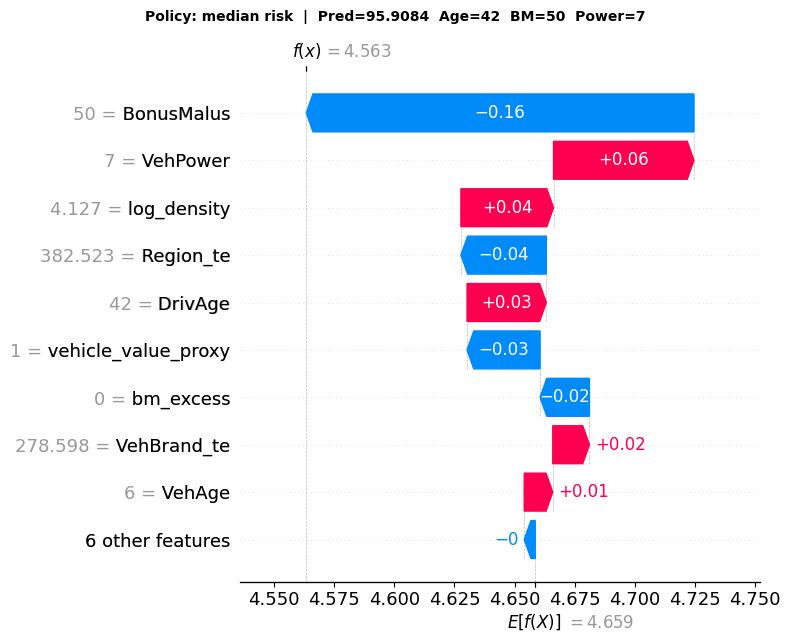

Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/waterfall_lgbm_median_risk.png


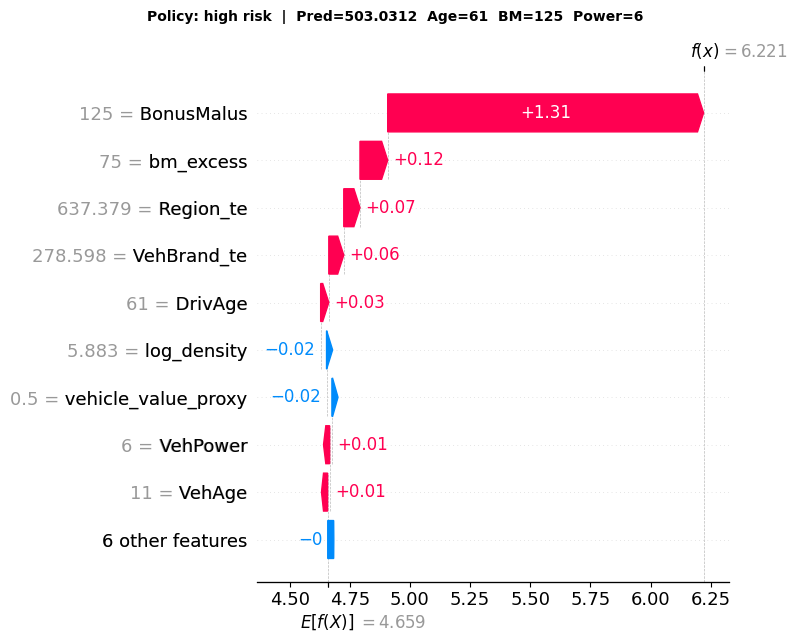

Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/waterfall_lgbm_high_risk.png


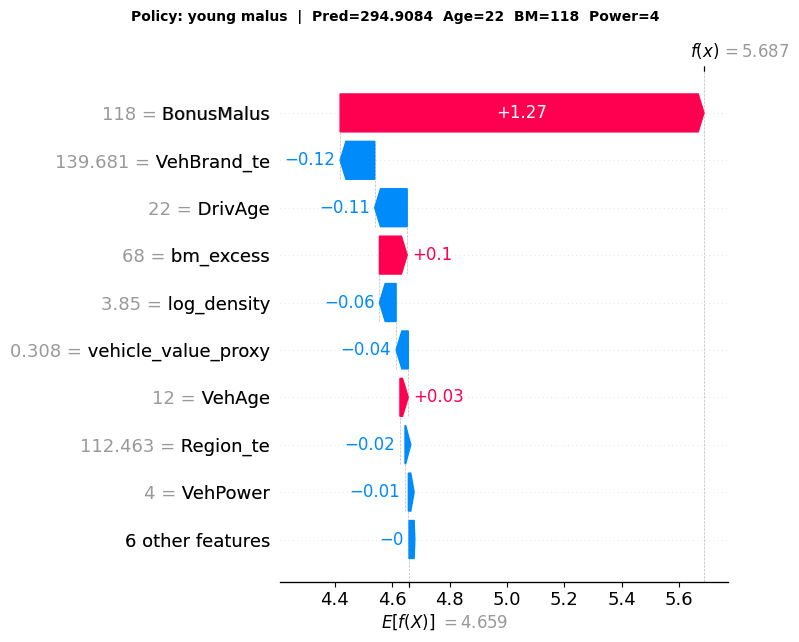

Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/waterfall_lgbm_young_malus.png


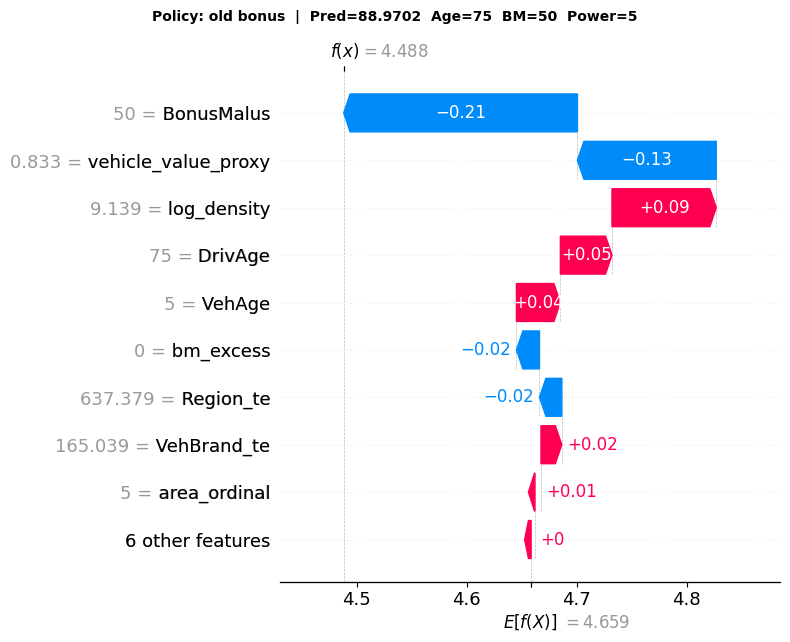

Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/waterfall_lgbm_old_bonus.png


In [15]:
# ── Waterfall Plots: 5 Representative Policies ───────────────────────────────
# Waterfall shows how each feature pushes a single policy's prediction above or
# below the population average.  We select 5 policies that tell different stories:
#
#   low_risk     — lowest predicted pure premium (safest driver in sample)
#   median_risk  — 50th percentile (a "typical" policy)
#   high_risk    — highest predicted pure premium (most dangerous)
#   young_malus  — youngest driver with BonusMalus > 100 (canonical high-risk profile)
#   old_bonus    — oldest driver with BonusMalus = 50 (experienced safe driver)
#
# For each we show the top 10 SHAP contributors in waterfall format.

policy_criteria = {
    'low_risk':   int(np.argmin(preds_lgbm)),
    'median_risk': int(np.argsort(preds_lgbm)[N_EXPLAIN // 2]),
    'high_risk':  int(np.argmax(preds_lgbm)),
    # Young driver (< 26) in malus zone (BM > 100): highest combined risk profile
    'young_malus': int(
        np.where(
            (X_holdout_df['DrivAge'].values < 26) & (X_holdout_df['BonusMalus'].values > 100)
        )[0][0]
        if np.any((X_holdout_df['DrivAge'].values < 26) & (X_holdout_df['BonusMalus'].values > 100))
        else int(np.argmax(preds_lgbm))   # fallback if no matching row
    ),
    # Senior driver (> 69) with perfect BM = 50: experienced but age-risk
    'old_bonus': int(
        np.where(
            (X_holdout_df['DrivAge'].values > 69) & (X_holdout_df['BonusMalus'].values == 50)
        )[0][0]
        if np.any((X_holdout_df['DrivAge'].values > 69) & (X_holdout_df['BonusMalus'].values == 50))
        else int(np.argsort(X_holdout_df['DrivAge'].values)[-1])  # fallback: oldest
    ),
}

print("Selected policies:")
for label, row_idx in policy_criteria.items():
    r = X_holdout_df.iloc[row_idx]
    print(f"  {label:12s}  row={row_idx:4d}  "
          f"pred={preds_lgbm[row_idx]:.4f}  "
          f"age={r['DrivAge']:.0f}  BM={r['BonusMalus']:.0f}  "
          f"power={r['VehPower']:.0f}")

base_val = float(explainer_lgbm.expected_value)

def _waterfall_fallback_lgbm(ax, shap_vals, feat_names, title):
    order  = np.argsort(np.abs(shap_vals))[::-1][:10]
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in shap_vals[order]]
    ax.barh([feat_names[i] for i in order], shap_vals[order], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (log scale)', fontsize=9)
    ax.set_title(title, fontsize=9)

for label, row_idx in policy_criteria.items():
    sv   = shap_values_lgbm[row_idx]
    pred = preds_lgbm[row_idx]
    r    = X_holdout_df.iloc[row_idx]

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.suptitle(
        f'Policy: {label.replace("_", " ")}  |  '
        f'Pred={pred:.4f}  Age={r["DrivAge"]:.0f}  '
        f'BM={r["BonusMalus"]:.0f}  Power={r["VehPower"]:.0f}',
        fontsize=10, fontweight='bold',
    )

    try:
        expl = shap.Explanation(
            values=sv,
            base_values=base_val,
            data=X_holdout_shap[row_idx],
            feature_names=feat_names,
        )
        shap.plots.waterfall(expl, max_display=10, show=False)
    except Exception:
        _waterfall_fallback_lgbm(ax, sv, feat_names, f'LightGBM — {label}')

    plt.tight_layout()
    fname = fig_dir / f'waterfall_lgbm_{label}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {fname}")

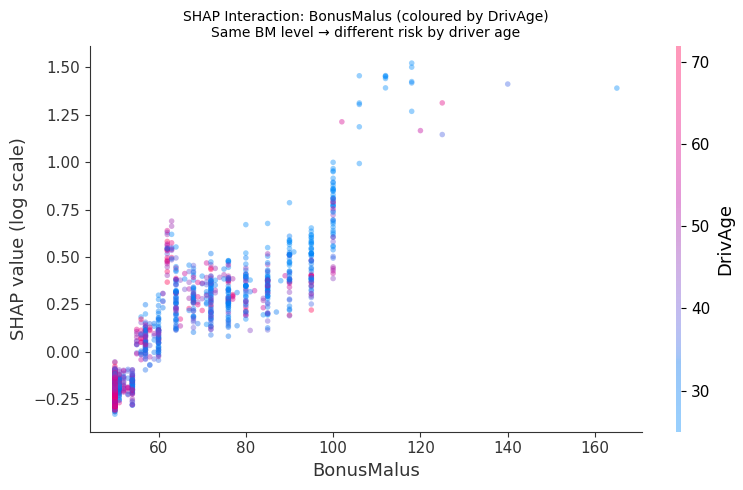

Saved → /Users/alexruppelt/Documents/Projects/tabpfn_analysis/figures/post2/shap_lgbm_bm_x_dripage_interaction.png

=== LightGBM SHAP Summary ===
TreeSHAP (2000 rows): 0.06s

Top 5 features by mean |SHAP|:
BonusMalus             0.24995
DrivAge                0.09839
log_density            0.08509
vehicle_value_proxy    0.06288
VehAge                 0.04176

Artifacts saved:
  results/interpretability/shap_values_lgbm.npy
  figures/post2/shap_lgbm_beeswarm.png
  figures/post2/shap_lgbm_importance_bar.png
  figures/post2/shap_lgbm_dependence_4features.png
  figures/post2/shap_{feature}_LightGBM.png  (×4 individual panels)
  figures/post2/waterfall_lgbm_{policy}.png  (×5 policies)
  figures/post2/shap_lgbm_bm_x_dripage_interaction.png

Next: run post2_tabpfn.ipynb Step 9 to compare LightGBM vs XGBoost vs TabPFN SHAP.


In [16]:
# ── Interaction: BonusMalus × DrivAge ────────────────────────────────────────
# This is the most important interaction in motor insurance: the same BM of 80
# (slight malus) means very different things for a 22-year-old vs a 50-year-old.
#
# We use shap.dependence_plot with interaction_index='DrivAge' to colour the
# BonusMalus dependence by driver age — this reveals the interaction directly.

fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(
    feat_names.index('BonusMalus'),
    shap_values_lgbm,
    X_holdout_shap,
    feature_names=feat_names,
    interaction_index=feat_names.index('DrivAge'),
    ax=ax,
    show=False,
    alpha=0.4,
)
ax.set_title('SHAP Interaction: BonusMalus (coloured by DrivAge)\n'
             'Same BM level → different risk by driver age', fontsize=10)
ax.set_xlabel('BonusMalus')
ax.set_ylabel('SHAP value (log scale)')
plt.tight_layout()
fname_interact = fig_dir / 'shap_lgbm_bm_x_dripage_interaction.png'
plt.savefig(fname_interact, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname_interact}")

# ── Interpretability summary ─────────────────────────────────────────────────
print("\n=== LightGBM SHAP Summary ===")
print(f"TreeSHAP ({N_EXPLAIN} rows): {t_shap:.2f}s")
print(f"\nTop 5 features by mean |SHAP|:")
print(feat_imp_df.head(5).round(5).to_string())
print(f"\nArtifacts saved:")
print(f"  results/interpretability/shap_values_lgbm.npy")
print(f"  figures/post2/shap_lgbm_beeswarm.png")
print(f"  figures/post2/shap_lgbm_importance_bar.png")
print(f"  figures/post2/shap_lgbm_dependence_4features.png")
print(f"  figures/post2/shap_{{feature}}_LightGBM.png  (×4 individual panels)")
print(f"  figures/post2/waterfall_lgbm_{{policy}}.png  (×5 policies)")
print(f"  figures/post2/shap_lgbm_bm_x_dripage_interaction.png")
print(f"\nNext: run post2_tabpfn.ipynb Step 9 to compare LightGBM vs XGBoost vs TabPFN SHAP.")